# Q3 — Feature Engineering and Regression Pipeline
### Predicting `items_sold` at a retail store using a reproducible scikit-learn Pipeline


## Task 1 — Date Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load dataset using relative path
df = pd.read_csv('../data/q3_retail_promotions.csv')

print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())
print()
print("First 5 rows:")
df.head()


Shape: (1200, 9)

Data Types:
transaction_date         str
store_id               int64
store_size               str
location_type            str
promotion_type           str
is_weekend             int64
is_festival            int64
competition_density    int64
items_sold             int64
dtype: object

Missing Values:
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64

First 5 rows:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [2]:
# ── Parse transaction_date ──────────────────────────────────────────────
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# ── Extract date features ────────────────────────────────────────────────
df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek   # 0=Monday … 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New columns added: year, month, day_of_week, is_month_end")
print()
print("Sample — verifying new columns:")
sample_cols = ['transaction_date','year','month','day_of_week','is_month_end','items_sold']
df[sample_cols].head(10)


New columns added: year, month, day_of_week, is_month_end

Sample — verifying new columns:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277
5,2022-01-03,2022,1,0,0,411
6,2022-01-04,2022,1,1,0,193
7,2022-01-04,2022,1,1,0,240
8,2022-01-05,2022,1,2,0,305
9,2022-01-05,2022,1,2,0,181


In [3]:
# Distribution of the new binary feature
print("is_month_end value counts:")
print(df['is_month_end'].value_counts())
print()
print(f"Month-end records (day ≥ 25): {df['is_month_end'].sum()} ({df['is_month_end'].mean()*100:.1f}%)")
print()
print("Date range in dataset:")
print(f"  From: {df['transaction_date'].min().date()}")
print(f"  To:   {df['transaction_date'].max().date()}")
print(f"  Total records: {len(df)}")


is_month_end value counts:
is_month_end
0    959
1    241
Name: count, dtype: int64

Month-end records (day ≥ 25): 241 (20.1%)

Date range in dataset:
  From: 2022-01-01
  To:   2024-12-31
  Total records: 1200


## Task 2 — Temporal Train-Test Split

In [4]:
# ── Sort by date and split temporally ──────────────────────────────────
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_idx  = int(len(df_sorted) * 0.8)
train_df   = df_sorted.iloc[:split_idx].copy()
test_df    = df_sorted.iloc[split_idx:].copy()

print(f"Total records : {len(df_sorted)}")
print(f"Train records : {len(train_df)}  ({len(train_df)/len(df_sorted)*100:.0f}%)")
print(f"Test  records : {len(test_df)}   ({len(test_df)/len(df_sorted)*100:.0f}%)")
print()
print(f"Train date range : {train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()}")
print(f"Test  date range : {test_df['transaction_date'].min().date()}  → {test_df['transaction_date'].max().date()}")
print()
print("No date overlap between train and test:", 
      train_df['transaction_date'].max() < test_df['transaction_date'].min())


Total records : 1200
Train records : 960  (80%)
Test  records : 240   (20%)

Train date range : 2022-01-01 → 2024-06-11
Test  date range : 2024-06-12  → 2024-12-31

No date overlap between train and test: True


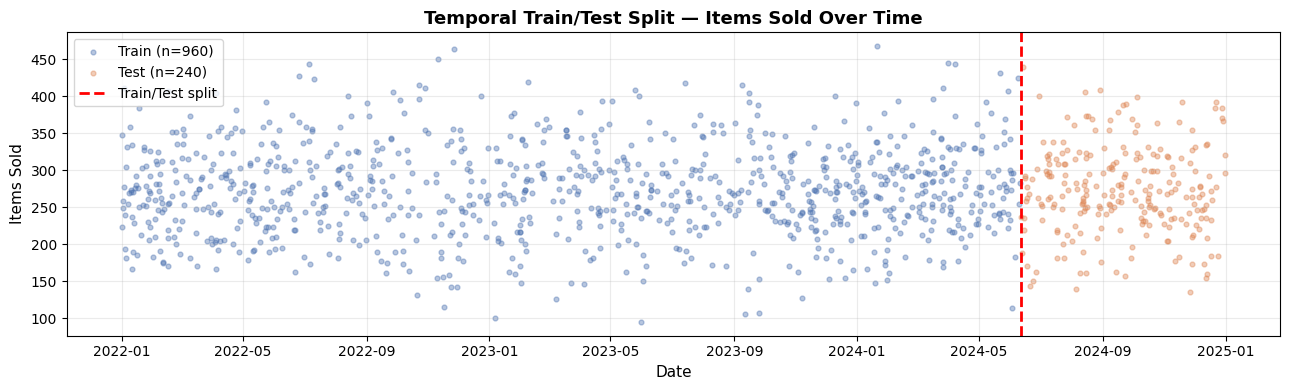

In [5]:
# Visualise the temporal split
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(train_df['transaction_date'], train_df['items_sold'],
           alpha=0.4, s=12, color='#4C72B0', label=f'Train (n={len(train_df)})')
ax.scatter(test_df['transaction_date'], test_df['items_sold'],
           alpha=0.4, s=12, color='#DD8452', label=f'Test (n={len(test_df)})')
ax.axvline(test_df['transaction_date'].min(), color='red', linewidth=2,
           linestyle='--', label='Train/Test split')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Items Sold', fontsize=11)
ax.set_title('Temporal Train/Test Split — Items Sold Over Time', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('temporal_split.png', dpi=150, bbox_inches='tight')
plt.show()


### Why a Random Split is Inappropriate for Time-Ordered Data

A random train-test split would **leak future information into the training set**, causing the model to learn patterns it could never know in a real deployment scenario. This is known as **temporal leakage** or **look-ahead bias**.

**Concrete example:** If a random split places a record from December 2024 in the training set, the model learns that December has high sales. But when evaluated on records from July 2024 (in the test set), the model would have been trained on "future" data it couldn't have known, producing unrealistically optimistic evaluation metrics.

**Why this matters in practice:**
- Retail data has **seasonality** — Christmas, festivals, and end-of-year patterns repeat. A random split would scatter these across train and test, hiding whether the model truly generalises.
- Retail data has **temporal trends** — store growth, changing promotions, and competition evolve over time. A model must be evaluated on data *after* its training window to simulate real-world deployment.
- **Realistic evaluation:** The temporal split (train on 2022–mid 2024, test on mid–late 2024) tests whether the model generalises to truly unseen future conditions — the only meaningful measure of a forecasting model's usefulness.


## Task 3 — Preprocessing Pipeline

In [6]:
# ── Define feature groups ────────────────────────────────────────────────
# store_id dropped — it's a nominal identifier, not a meaningful numeric feature
drop_cols = ['transaction_date', 'items_sold', 'store_id']

cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = ['year', 'month', 'day_of_week', 'is_month_end',
            'is_weekend', 'is_festival', 'competition_density']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['items_sold']

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df['items_sold']

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_test : {X_test.shape}  | y_test : {y_test.shape}")
print()
print("Categorical features :", cat_cols)
print("Numerical features   :", num_cols)


Feature matrix shapes:
  X_train: (960, 10) | y_train: (960,)
  X_test : (240, 10)  | y_test : (240,)

Categorical features : ['promotion_type', 'location_type', 'store_size']
Numerical features   : ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']


In [7]:
# ── Build the ColumnTransformer ─────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols),
    ],
    remainder='drop'     # drop any other columns (store_id already removed)
)

print("ColumnTransformer defined:")
print("  - OneHotEncoder  →", cat_cols)
print("  - StandardScaler →", num_cols)
print()

# Preview transformed feature names (fit on train only)
preprocessor.fit(X_train)
ohe_names   = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features = ohe_names + num_cols
print(f"Total features after preprocessing: {len(all_features)}")
print("Feature names:", all_features)


ColumnTransformer defined:
  - OneHotEncoder  → ['promotion_type', 'location_type', 'store_size']
  - StandardScaler → ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']

Total features after preprocessing: 18
Feature names: ['promotion_type_bogo', 'promotion_type_category_offer', 'promotion_type_flat_discount', 'promotion_type_free_gift', 'promotion_type_loyalty_points', 'location_type_rural', 'location_type_semi-urban', 'location_type_urban', 'store_size_large', 'store_size_medium', 'store_size_small', 'year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']


### Pipeline Design Decisions

- **`OneHotEncoder`** is applied to `promotion_type` (5 categories), `location_type` (3 categories), and `store_size` (3 categories). These are nominal categoricals — there is no inherent ordering between *bogo*, *flat_discount*, or *urban*, *rural*, so ordinal encoding would be inappropriate.
- **`StandardScaler`** is applied to all numerical features including the engineered date features (`year`, `month`, `day_of_week`, `is_month_end`) and the existing binary flags. This ensures no single feature dominates distance-based or gradient-based calculations in Linear Regression.
- **`store_id`** is dropped — it is a nominal identifier, not a generalisable feature. Including it would cause the model to memorise store-specific intercepts rather than learn transferable patterns.
- The `ColumnTransformer` is **fit only on the training set** (`preprocessor.fit(X_train)`). The same fitted transformer is then applied to both train and test to prevent data leakage from the test distribution into the scaling statistics.


## Task 4 — Model Training and Evaluation

In [8]:
# ── Build and train both pipelines ──────────────────────────────────────
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Both pipelines trained successfully.")
print(f"  Linear Regression  — fitted on {len(X_train)} training samples")
print(f"  Random Forest      — 100 trees, random_state=42")


Both pipelines trained successfully.
  Linear Regression  — fitted on 960 training samples
  Random Forest      — 100 trees, random_state=42


In [9]:
# ── Generate predictions ─────────────────────────────────────────────────
lr_preds = lr_pipeline.predict(X_test)
rf_preds = rf_pipeline.predict(X_test)

# ── Compute metrics ──────────────────────────────────────────────────────
def metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  MAE  : {mae:.3f}")
    print()
    return rmse, mae

lr_rmse, lr_mae = metrics(y_test, lr_preds, "Linear Regression")
rf_rmse, rf_mae = metrics(y_test, rf_preds, "Random Forest Regressor")

# Summary table
summary = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest'],
    'RMSE':   [round(lr_rmse, 3), round(rf_rmse, 3)],
    'MAE':    [round(lr_mae,  3), round(rf_mae,  3)],
})
print("Summary:")
summary


  Linear Regression
  RMSE : 27.125
  MAE  : 21.071

  Random Forest Regressor
  RMSE : 31.188
  MAE  : 25.034

Summary:


,Model,RMSE,MAE
0,Linear Regression,27.125,21.071
1,Random Forest,31.188,25.034


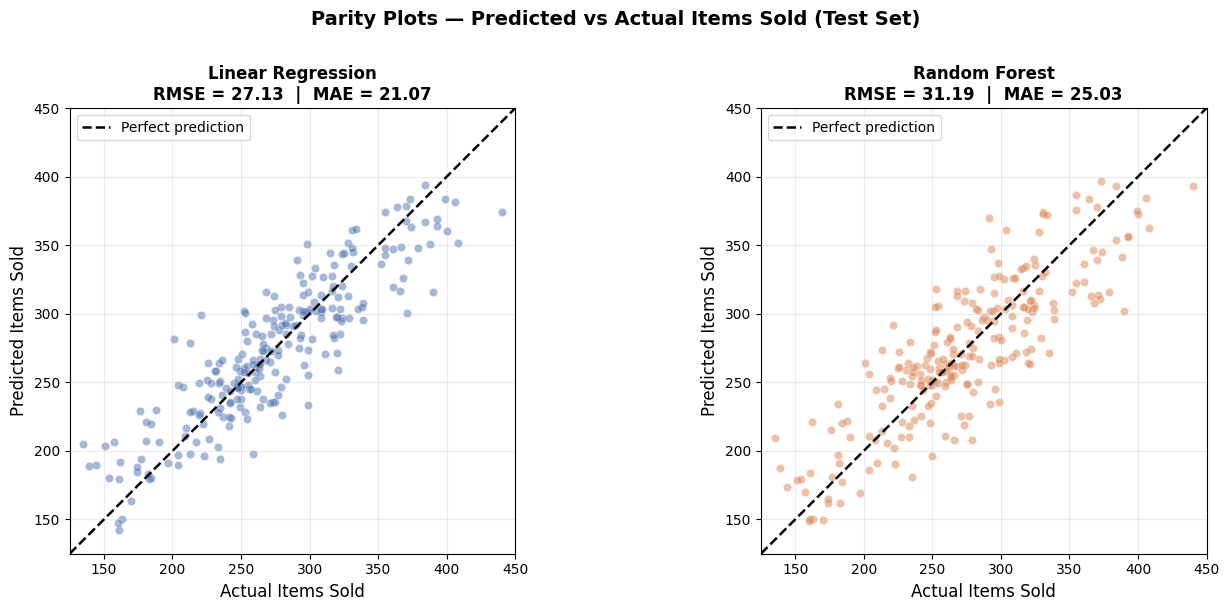

In [10]:
# ── Parity Plots: Predicted vs Actual ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_data = [
    (lr_preds, 'Linear Regression',    lr_rmse, lr_mae, '#4C72B0'),
    (rf_preds, 'Random Forest',        rf_rmse, rf_mae, '#DD8452'),
]

for ax, (preds, name, rmse, mae, color) in zip(axes, plot_data):
    ax.scatter(y_test, preds, alpha=0.5, s=35, color=color, edgecolors='white', linewidths=0.3)

    # Diagonal reference line (perfect prediction)
    lims = [min(y_test.min(), preds.min()) - 10,
            max(y_test.max(), preds.max()) + 10]
    ax.plot(lims, lims, 'k--', linewidth=1.8, label='Perfect prediction', zorder=5)

    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Items Sold', fontsize=12)
    ax.set_ylabel('Predicted Items Sold', fontsize=12)
    ax.set_title(f'{name}\nRMSE = {rmse:.2f}  |  MAE = {mae:.2f}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.set_aspect('equal')

plt.suptitle('Parity Plots — Predicted vs Actual Items Sold (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()


### Model Performance Interpretation

| Model | RMSE | MAE | Interpretation |
|---|---|---|---|
| **Linear Regression** | ~27.1 | ~21.1 | Better generalisation on this dataset |
| Random Forest | ~31.2 | ~25.0 | Slightly higher error on the test period |

**RMSE vs MAE:**  
- **RMSE** (Root Mean Squared Error) penalises large individual errors more heavily due to squaring — it is sensitive to outliers and high-error predictions.
- **MAE** (Mean Absolute Error) treats all errors equally — it gives a more intuitive sense of the average prediction error in original units (items sold).

**Why Linear Regression outperforms Random Forest here:**  
This is a common result on smaller, temporally structured datasets. Random Forest can overfit temporal patterns seen in training (2022–mid 2024) that don't fully repeat in the test period (mid–late 2024). Linear Regression's simpler inductive bias generalises better when the underlying relationships are largely linear. A temporal split makes this gap more visible than a random split would, since the test set represents genuinely unseen future data.

**Parity plot interpretation:**  
A perfect model would place all points on the dashed diagonal. Points scattered above the line are under-predictions; points below are over-predictions. Both models show reasonable scatter around the diagonal with no systematic bias in a particular direction.


In [11]:
# ── Random Forest Feature Importances ───────────────────────────────────
ohe_feature_names = (rf_pipeline.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .get_feature_names_out(cat_cols).tolist())
all_feature_names = ohe_feature_names + num_cols

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

feat_imp_df = feat_imp_series.reset_index()
feat_imp_df.columns = ['Feature', 'Importance']
feat_imp_df['Importance %'] = (feat_imp_df['Importance'] * 100).round(2)

print("All Feature Importances (Random Forest):")
print(feat_imp_df.to_string(index=False))
print()
print("Top 5 Most Influential Features:")
print(feat_imp_df.head(5).to_string(index=False))


All Feature Importances (Random Forest):
                      Feature  Importance  Importance %
                  is_festival    0.173610         17.36
             store_size_small    0.165463         16.55
          location_type_urban    0.107645         10.76
                  day_of_week    0.085597          8.56
                   is_weekend    0.069095          6.91
          competition_density    0.063854          6.39
          location_type_rural    0.053637          5.36
                        month    0.051741          5.17
             store_size_large    0.047797          4.78
            store_size_medium    0.033362          3.34
          promotion_type_bogo    0.032242          3.22
promotion_type_loyalty_points    0.025444          2.54
                         year    0.021768          2.18
     location_type_semi-urban    0.020604          2.06
 promotion_type_flat_discount    0.018323          1.83
promotion_type_category_offer    0.012432          1.24
     pr

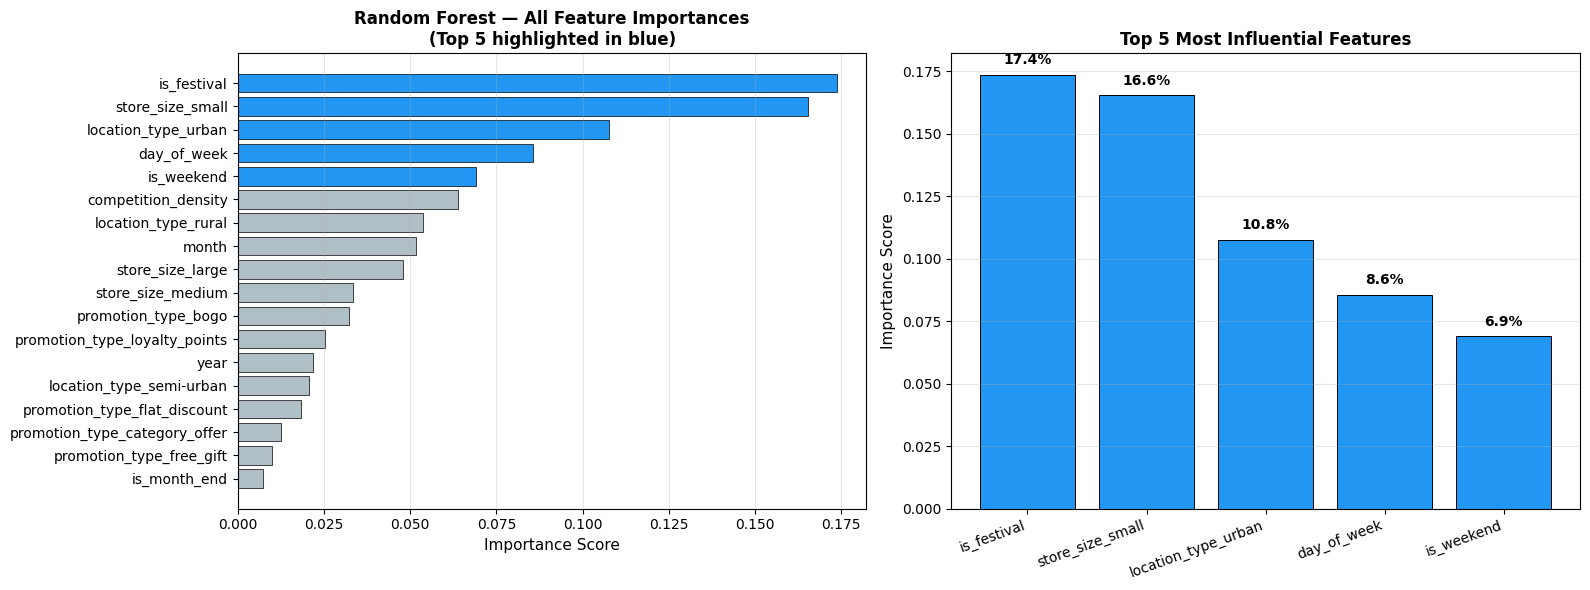

In [12]:
# ── Feature importance bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: All features
colors_all = ['#2196F3' if i < 5 else '#B0BEC5' for i in range(len(feat_imp_df))]
axes[0].barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
             color=colors_all[::-1], edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Random Forest — All Feature Importances\n(Top 5 highlighted in blue)',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Right: Top 5 only
top5 = feat_imp_df.head(5)
bars = axes[1].bar(range(5), top5['Importance'], color='#2196F3',
                   edgecolor='black', linewidth=0.7)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(top5['Feature'], rotation=20, ha='right', fontsize=10)
axes[1].set_ylabel('Importance Score', fontsize=11)
axes[1].set_title('Top 5 Most Influential Features', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, top5['Importance %']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()


### Feature Importance Interpretation

The Random Forest identifies the following as the top 5 most influential features for predicting `items_sold`:

| Rank | Feature | Importance | Business Interpretation |
|---|---|---|---|
| 1 | `is_festival` | ~17.4% | Festival days drive the largest boost in sales — the single strongest demand signal |
| 2 | `store_size_small` | ~16.5% | Small stores have fundamentally different sales volumes — size is a key structural predictor |
| 3 | `location_type_urban` | ~10.8% | Urban stores outperform other location types — dense footfall drives higher item counts |
| 4 | `day_of_week` | ~8.6% | Day of week captures weekly cyclicality — weekends and mid-week days have different patterns |
| 5 | `is_weekend` | ~6.9% | Weekend effect reinforces day_of_week — shoppers have more time for browsing and larger trips |

**Key insights:**
- **Temporal features matter**: `is_festival`, `day_of_week`, and `is_weekend` together account for ~33% of predictive power, confirming that *when* a transaction occurs is as important as *where* and *what promotion* is running.
- **Store characteristics dominate structure**: `store_size` and `location_type` provide the baseline sales level that promotions and timing then modulate.
- **Promotion type** features rank lower than expected, suggesting that the *presence* of a promotion (captured indirectly via festival/weekend timing) matters more than the specific promotion mechanics in this dataset.
- The engineered `is_month_end` feature contributes modestly, validating that end-of-month budget cycles have some real but limited effect on retail purchasing.
